# `miescattering` tutorial

This notebook teaches the single-particle and ensemble-scattering tools in `empylib.miescattering`, from efficiencies and coefficients to angular phase functions and packed-particle corrections.

**Learning goals**

- compute efficiency factors for single and coated spheres
- inspect scattering coefficients and angular amplitudes explicitly
- build ensemble quantities from particle size distributions and phase functions

**Notebook design**

- every runnable cell calls the public `empylib` API directly
- parameter meanings are explained in markdown and in short inline comments
- outputs are inspected in the same notebook so you can see what each function returns
- the core path is offline-first; internet-backed examples live in clearly marked optional appendices

In [1]:
from pathlib import Path
import os
import sys

current = Path.cwd().resolve()
for candidate in (current, *current.parents):
    if (candidate / "empylib").exists() and (candidate / "docs").exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the EMPI Lib repository root.")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.figsize"] = (7, 3)

import empylib.miescattering as mie

## Single homogeneous sphere

**Functions used**

- mie.scatter_efficiency

**Problem we are solving**

The most common entry point is the scattering efficiency of one sphere embedded in a host medium. This gives absorption, scattering, and asymmetry factor on a wavelength grid.

**Parameter guide for this example**

- `wavelength`: wavelength grid in micrometers
- `Nh`: refractive index of the host medium
- `Np_shells`: refractive index of the particle; a single scalar or wavelength-dependent spectrum for a homogeneous sphere
- `D`: particle diameter in micrometers

**Outputs to inspect**

- `qabs`: absorption efficiency
- `qsca`: scattering efficiency
- `gcos`: asymmetry factor

qabs shape: (121,)
g range: 0.463369357055584 0.7348687429056766


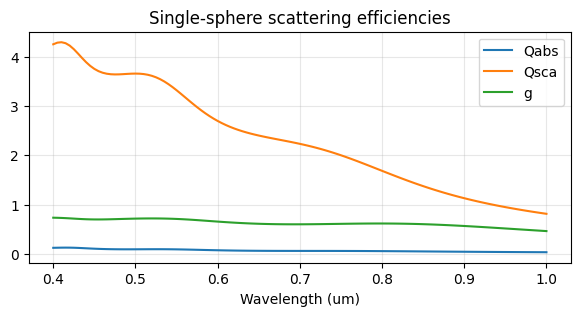

In [2]:
lam = np.linspace(0.40, 1.00, 121)

qabs, qsca, gcos = mie.scatter_efficiency(
    lam,
    1.50,                     # host refractive index
    2.35 + 0.01j + 0 * lam,  # particle refractive index
    0.30,                     # particle diameter in micrometers
)

print("qabs shape:", qabs.shape)
print("g range:", float(np.min(gcos)), float(np.max(gcos)))

fig, ax = plt.subplots()
ax.plot(lam, qabs, label="Qabs")
ax.plot(lam, qsca, label="Qsca")
ax.plot(lam, gcos, label="g")
ax.set_xlabel("Wavelength (um)")
ax.set_title("Single-sphere scattering efficiencies")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

**How to read the result**

The efficiency factors are dimensionless and tell you how strongly the particle interacts with light relative to its geometric cross section. The asymmetry factor `g` stays between `-1` and `1`.

**Common pitfalls**

- Diameter is in micrometers
- The host and particle inputs can be scalar or wavelength-dependent, but they must still be physically compatible over the same spectral range

**Try this next**

- Change the diameter to see how resonances move with particle size
- Replace the constant particle index with a real material from `nklib`

## Coated sphere and Mie coefficients

**Functions used**

- mie.scatter_efficiency
- mie.scatter_coefficients

**Problem we are solving**

A core-shell particle uses the same public API, but now the particle index and diameter are lists ordered from inner core to outer shell. You can also request the full coefficient arrays for detailed analysis.

**Parameter guide for this example**

- `Np_shells`: list of refractive indices, one per shell from center outward
- `D`: list or array of shell diameters, again from center outward
- `scatter_coefficients`: returns the `a_n` and `b_n` coefficient arrays instead of aggregated efficiencies

**Outputs to inspect**

- `qabs_cs`, `qsca_cs`, `gcos_cs`: efficiency factors for the coated particle
- `an`, `bn`: Mie coefficient arrays

In [3]:
np_shells = [
    1.80 + 0.00j + 0 * lam,
    2.35 + 0.01j + 0 * lam,
]
d_shells = np.array([0.18, 0.30])

qabs_cs, qsca_cs, gcos_cs = mie.scatter_efficiency(
    lam,
    1.50,
    np_shells,  # core and shell refractive indices
    d_shells,   # core and outer-shell diameters
)

an, bn = mie.scatter_coefficients(
    lam,
    1.50,
    np_shells,
    d_shells,
)

print("Coefficient array shape:", an.shape)
print("First coated-sphere g value:", gcos_cs[0])

Coefficient array shape: (121, 8)
First coated-sphere g value: 0.759017218789


**How to read the result**

This is the same user-facing workflow as the homogeneous sphere, but the particle is now specified as a radial stack. The coefficient arrays are useful when you need mode-by-mode diagnostics.

**Common pitfalls**

- The shell diameters must increase from the core to the outer shell
- Keep the shell-ordering of `Np_shells` and `D` consistent

**Try this next**

- Add a third shell to explore a multilayer sphere
- Plot the magnitude of selected `a_n` and `b_n` modes versus wavelength

## Angular amplitudes and Stokes / Mueller terms

**Functions used**

- mie.scatter_amplitude
- mie.scatter_stokes

**Problem we are solving**

If you care about angular redistribution or polarization, you need more than integrated efficiencies. These functions return the scattering amplitudes and the Mueller-matrix terms on an angle grid.

**Parameter guide for this example**

- `theta`: scattering angle grid in radians
- `scatter_amplitude`: returns `S1` and `S2`
- `scatter_stokes`: returns `S11`, `S12`, `S33`, and `S34`

**Outputs to inspect**

- `s1`, `s2`: amplitude functions
- `s11`, `s12`, `s33`, `s34`: angular Stokes / Mueller terms

S1 shape: (181, 121)
S11 shape: (181, 121)


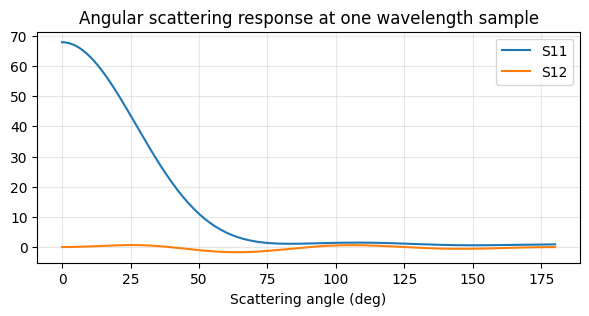

In [4]:
theta = np.linspace(0.0, np.pi, 181)

s1, s2 = mie.scatter_amplitude(
    lam,
    1.50,
    2.35 + 0.01j + 0 * lam,
    0.30,
    theta=theta,  # scattering angles in radians
)

s11, s12, s33, s34 = mie.scatter_stokes(
    lam,
    1.50,
    2.35 + 0.01j + 0 * lam,
    0.30,
    theta=theta,
)

print("S1 shape:", s1.shape)
print("S11 shape:", s11.shape)

fig, ax = plt.subplots()
wavelength_index = 20
ax.plot(np.degrees(theta), s11[:, wavelength_index], label="S11")
ax.plot(np.degrees(theta), s12[:, wavelength_index], label="S12")
ax.set_xlabel("Scattering angle (deg)")
ax.set_title("Angular scattering response at one wavelength sample")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

**How to read the result**

The angular functions resolve how the particle redistributes light by direction and polarization. This is the right level of detail when you need a phase function for radiative transfer or a polarization observable.

**Common pitfalls**

- Angles are in radians on input even if you plot them in degrees
- The returned arrays are angle by wavelength, so use the correct axis when slicing

**Try this next**

- Compare two wavelengths at the same particle size
- Use the angular data to build a custom phase-function diagnostic

## Phase functions and ensemble-averaged scattering

**Functions used**

- mie.phase_scatt_HG
- mie.scatter_from_phase_function
- mie.structure_factor_PY
- mie.phase_scatt_ensemble
- mie.cross_section_ensemble

**Problem we are solving**

Real particulate media usually contain a size distribution, and dense systems can also show dependent scattering. This section shows how to move from a simple phase function to a distributed ensemble and then to ensemble cross sections.

**Parameter guide for this example**

- `d_bins`: particle diameters used to describe the distribution
- `size_dist`: relative weights for each diameter bin
- `fv`: particle volume fraction used by the dependent-scattering corrections
- `phase_function=True`: request the ensemble phase function DataFrame from `cross_section_ensemble`

**Outputs to inspect**

- `hg_phase`: Henyey-Greenstein phase function
- `qsca_hg`, `g_hg`: scattering quantities recovered from that phase function
- `structure_factor`: Percus-Yevick structure factor
- `phase_ensemble`: ensemble phase function
- `cabs`, `csca`, `g_av`, `phase_df`: ensemble-averaged optical quantities

HG-derived qsca and g: [ 1.0016335  1.0016335  1.0016335] [ 0.70047425  0.70047425  0.70047425]


,0.400,0.405,0.410,0.415,0.420,0.425,0.430,0.435,0.440,0.445,...,0.955,0.960,0.965,0.970,0.975,0.980,0.985,0.990,0.995,1.000
0.0,4.355057,4.577340,4.511941,4.441655,4.356988,4.256971,4.148428,4.040758,3.940673,3.850200,...,0.347219,0.339533,0.332019,0.324678,0.317507,0.310503,0.303665,0.296989,0.290474,0.284116
1.0,4.349207,4.571476,4.506298,4.436224,4.351779,4.252001,4.143705,4.036272,3.936404,3.846125,...,0.347121,0.339436,0.331926,0.324587,0.317418,0.310417,0.303581,0.296907,0.290394,0.284039
2.0,4.331702,4.553926,4.489412,4.419968,4.336187,4.237125,4.129567,4.022845,3.923626,3.833925,...,0.346825,0.339148,0.331646,0.324314,0.317153,0.310158,0.303329,0.296662,0.290156,0.283807
3.0,4.302676,4.524820,4.461402,4.393001,4.310319,4.212442,4.106105,4.000560,3.902418,3.813674,...,0.346332,0.338669,0.331179,0.323860,0.316711,0.309728,0.302910,0.296255,0.289759,0.283420
4.0,4.262351,4.484369,4.422469,4.355511,4.274351,4.178117,4.073472,3.969561,3.872910,3.785495,...,0.345643,0.337999,0.330527,0.323226,0.316093,0.309127,0.302325,0.295685,0.289204,0.282880


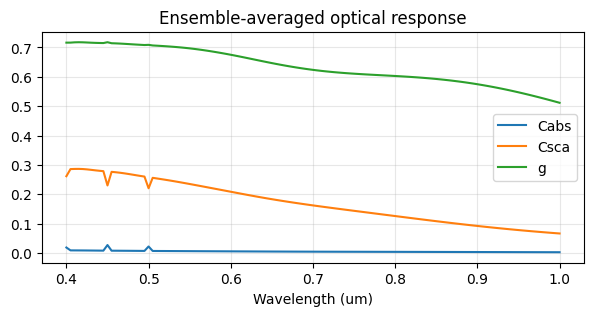

In [5]:
d_bins = np.linspace(0.20, 0.40, 7)
size_dist = np.exp(-((d_bins - 0.30) / 0.05) ** 2)
size_dist = size_dist / size_dist.sum()

hg_phase = mie.phase_scatt_HG(
    lam,
    np.full(lam.size, 0.7),  # asymmetry factor as a wavelength-dependent array
    qsca=np.ones_like(lam),  # normalization helper for the HG phase function
    theta=theta,
)

qsca_hg, g_hg = mie.scatter_from_phase_function(hg_phase)

structure_factor = mie.structure_factor_PY(
    lam,
    1.50,
    d_bins,
    fv=0.08,              # particle volume fraction
    theta=theta,
    size_dist=size_dist,  # distribution weights over d_bins
)

phase_ensemble = mie.phase_scatt_ensemble(
    lam,
    1.50,
    2.35 + 0.01j + 0 * lam,
    d_bins,
    fv=0.08,
    size_dist=size_dist,
    theta=theta,
)

cabs, csca, g_av, phase_df = mie.cross_section_ensemble(
    lam,
    1.50,
    2.35 + 0.01j + 0 * lam,
    d_bins,
    fv=0.08,
    size_dist=size_dist,
    theta=theta,
    phase_function=True,  # also return the phase function DataFrame
)

print("HG-derived qsca and g:", qsca_hg[:3], g_hg[:3])
display(phase_df.head())

fig, ax = plt.subplots()
ax.plot(lam, cabs, label="Cabs")
ax.plot(lam, csca, label="Csca")
ax.plot(lam, g_av, label="g")
ax.set_xlabel("Wavelength (um)")
ax.set_title("Ensemble-averaged optical response")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

**How to read the result**

The ensemble functions package several common particulate-medium tasks: approximate phase functions, dependent-scattering corrections, and size-distribution averaging. The returned DataFrame is convenient when you need a tabular phase function downstream.

**Common pitfalls**

- The size distribution weights should be normalized if you want them to behave as probabilities
- Dense suspensions can be sensitive to the volume fraction and dependent-scattering model you choose
- If you request `phase_function=True`, remember that the phase-function output is a DataFrame in addition to the scalar spectra

**Try this next**

- Replace the Gaussian size distribution with a log-normal one
- Compare the ensemble result with a single-diameter result to see how much the size spread matters